In [3]:
#importing datasets
import pandas as pd
import numpy as np
#importing curated dataset
fact_inventory = pd.read_csv('C:\\Users\\ishaan karwayun\\OneDrive - Symbiosis International University\\Desktop\\BITSOM\\Retail_demand_and_inventory_planner\\curated_dts\\fact_inventory_store_sku_daily.csv')
fact_sales = pd.read_csv('C:\\Users\\ishaan karwayun\\OneDrive - Symbiosis International University\\Desktop\\BITSOM\\Retail_demand_and_inventory_planner\\curated_dts\\fact_sales_store_sku_daily.csv')
replenishment = pd.read_csv('C:\\Users\\ishaan karwayun\\OneDrive - Symbiosis International University\\Desktop\\BITSOM\\Retail_demand_and_inventory_planner\\curated_dts\\replenishment_inputs_store_sku.csv')
PO = pd.read_csv('C:\\Users\\ishaan karwayun\\OneDrive - Symbiosis International University\\Desktop\\BITSOM\\Retail_demand_and_inventory_planner\\Retail Demand Forecasting & Inventory Replenishment Planner\\purchase_orders.csv')

In [4]:
products = pd.read_json('Retail Demand Forecasting & Inventory Replenishment Planner\products.json')
products.head()

,sku_id,category,price,cost,shelf_life_days,moq_units
0,SKU0001,PersonalCare,392.55,269.72,510,12
1,SKU0002,HomeCare,372.13,210.62,536,12
2,SKU0003,Snacks,220.56,169.92,396,48
3,SKU0004,Snacks,539.79,385.07,420,24
4,SKU0005,Beverages,262.43,175.54,373,12


In [5]:
#converting date column to datetime and creating week_start_date column in fact_sales
fact_sales['date'] = pd.to_datetime(fact_sales['date'])
fact_sales['week_start_date'] = fact_sales['date'] - pd.to_timedelta(fact_sales['date'].dt.weekday,unit = 'd')

In [6]:
weekly_fact_sales = fact_sales.groupby(['week_start_date']).agg(
    units_sold =('units_sold','sum')
    ,true_demand_units = ('true_demand_units','sum')
    ,stockount_censored_units = ('stockout_censored_units','sum')
    ,revenue = ('revenue','sum')
    ,margin_proxy = ('margin_proxy','sum')
    ,day_of_the_week = ('day_of_week','first')
    ,promo_flag = ('promo_flag','mean')
    ,holiday_flag = ('holiday_flag','mean')
).reset_index()

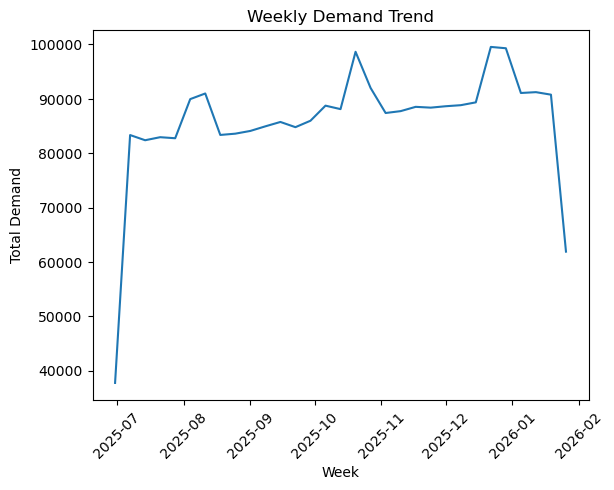

In [7]:
#Visualizing weekly demand trend
import matplotlib.pyplot as plt
weekly_demand =  weekly_fact_sales.groupby('week_start_date').agg(
    total_demand=('true_demand_units', 'sum')
).reset_index()
plt.figure()
plt.plot(weekly_demand['week_start_date'], weekly_demand['total_demand'])
plt.xlabel('Week')
plt.ylabel('Total Demand')
plt.title('Weekly Demand Trend')
plt.xticks(rotation=45)
plt.show()

In [8]:
# Top SKUs by demand and revenue
SKU_data = fact_sales.groupby('sku_id').agg(Demand = ('true_demand_units','sum'), Revenue = ('revenue','sum')).reset_index()
SKU_data = SKU_data.merge(products[['sku_id','category']], on = 'sku_id', how = 'left')

In [9]:
SKU_data['Revenue'] = round(SKU_data['Revenue'],2)

In [10]:
# Displaying top 5 SKUs by demand and revenue
top_demand = SKU_data.sort_values(by='Demand', ascending = False).head(5)
top_revenue = SKU_data.sort_values(by='Revenue',ascending= False).head(5)
print(f'Top SKUs by demand are :\n{top_demand}')
print(f'Top SKUs by revenue are :\n{top_revenue}')

Top SKUs by demand are :
     sku_id  Demand    Revenue category
43  SKU0044   51226  974477.07  Grocery
81  SKU0082   50830  326002.69  Grocery
76  SKU0077   50786  986457.80  Grocery
35  SKU0036   50737  965534.60  Grocery
59  SKU0060   50724  995398.90  Grocery
Top SKUs by revenue are :
     sku_id  Demand     Revenue category
50  SKU0051   50327  1768502.50  Grocery
18  SKU0019   50642  1627164.40  Grocery
57  SKU0058   31244  1495138.20   Snacks
52  SKU0053   38379  1489297.73    Dairy
22  SKU0023   38098  1404723.20    Dairy


In [11]:
fact_sales = fact_sales.merge(products[['sku_id','category']],on='sku_id',how = 'left')

In [12]:
#Forecasting
#Baseline- Moving average and seasonal naive
#1 moving average   

In [13]:
fact_sales = fact_sales.sort_values('date')
#average of last 7 days
avg_last_7d = fact_sales['true_demand_units'].tail(7).mean()
#creating the 28 d forecast dataframe
forecast_dates = pd.date_range(start = fact_sales['date'].max() + pd.Timedelta(days=1), periods=28)
df_forecast = pd.DataFrame({
    'date':forecast_dates
    ,'forecast_units': avg_last_7d
})
print("Moving Average Forecast (First 5 days):")
print(df_forecast.head())

Moving Average Forecast (First 5 days):
        date  forecast_units
0 2026-01-31        7.714286
1 2026-02-01        7.714286
2 2026-02-02        7.714286
3 2026-02-03        7.714286
4 2026-02-04        7.714286


In [14]:
# Approach 2: seasonal naive (weekly):---
last_week_pattern = fact_sales['true_demand_units'].tail(7).values
#repeating that pattern 4 times
seasonal_naive_values = np.tile(last_week_pattern, 4)
df_sn_forecast = pd.DataFrame({
    'date': forecast_dates,
    'forecast_units': seasonal_naive_values
})
print("\nSeasonal Naive Forecast (First 5 days):")
print(df_sn_forecast.head())


Seasonal Naive Forecast (First 5 days):
        date  forecast_units
0 2026-01-31               2
1 2026-02-01              30
2 2026-02-02               6
3 2026-02-03               6
4 2026-02-04               7


In [15]:
#defining as of date for forecasting
label_forecasting_days = 28
last_date = fact_sales['date'].max()
as_of_date = last_date - pd.Timedelta(days = label_forecasting_days)

In [16]:
fact_sales['revenue'].sum()

np.float64(54451180.89999999)

In [17]:
fact_sales = pd.get_dummies(fact_sales, columns=['category'], prefix='cat', dtype=int)

In [18]:
calendar = pd.read_csv('Retail Demand Forecasting & Inventory Replenishment Planner\calendar.csv')
calendar['date'] = pd.to_datetime(calendar['date'])
fact_sales = fact_sales.merge(calendar[['date','is_weekend']], on = 'date', how = 'left')

In [19]:
fact_inventory['date'] = pd.to_datetime(fact_inventory['date'])

In [20]:
fact_sales = fact_sales.merge(fact_inventory[['date','store_id','sku_id','avg_28d_demand']], on = ['date','store_id','sku_id'], how = 'left')

In [21]:
category_features = [col for col in fact_sales.columns if col.startswith('cat_')]

In [22]:
category_features

['cat_Beverages',
 'cat_Dairy',
 'cat_Grocery',
 'cat_HomeCare',
 'cat_PersonalCare',
 'cat_Snacks']

In [23]:
#ML model
#split the data based on as_of_date to allow 28 day forecast
Test_data = fact_sales[fact_sales['date'] > as_of_date]
Training_data = fact_sales[fact_sales['date'] < as_of_date]
features = ['day_of_week', 'promo_flag', 'holiday_flag', 'is_weekend', 'avg_28d_demand'] + category_features
target = ['true_demand_units']

# Target Encoding: Calculate means from Training only
store_map = Training_data.groupby('store_id')['true_demand_units'].mean()
sku_map = Training_data.groupby('sku_id')['true_demand_units'].mean()

# Map the historical averages to both sets
Training_data['store_encoded'] = Training_data['store_id'].map(store_map)
Training_data['sku_encoded'] = Training_data['sku_id'].map(sku_map)

Test_data['store_encoded'] = Test_data['store_id'].map(store_map)
Test_data['sku_encoded'] = Test_data['sku_id'].map(sku_map)

# Fill any new SKUs/Stores in the test set with the global average
Test_data['store_encoded'] = Test_data['store_encoded'].fillna(Training_data['true_demand_units'].mean())
Test_data['sku_encoded'] = Test_data['sku_encoded'].fillna(Training_data['true_demand_units'].mean())

# Create X and y for Training
X_train = Training_data[features]
Y_train = Training_data[target]

# Create X and y for Testing
X_test = Test_data[features]
y_test = Test_data[target]


C:\Users\ishaan karwayun\AppData\Local\Temp\ipykernel_24052\3513375912.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Training_data['store_encoded'] = Training_data['store_id'].map(store_map)
C:\Users\ishaan karwayun\AppData\Local\Temp\ipykernel_24052\3513375912.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Training_data['sku_encoded'] = Training_data['sku_id'].map(sku_map)
C:\Users\ishaan karwayun\AppData\Local\Temp\ipykernel_24052\3513375912.py:16: SettingWithCopyWarning: 
A value is trying t

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the smart model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Generate predictions for the test period
Test_data['forecast_units'] = model.predict(X_test)

c:\Users\ishaan karwayun\.anaconda\anagenda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\ishaan karwayun\AppData\Local\Temp\ipykernel_24052\2238438051.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Test_data['forecast_units'] = model.predict(X_test)


In [25]:
Test_data.head()

,date,store_id,sku_id,units_sold,true_demand_units,stockout_censored_units,revenue,margin_proxy,day_of_week,promo_flag,...,cat_Dairy,cat_Grocery,cat_HomeCare,cat_PersonalCare,cat_Snacks,is_weekend,avg_28d_demand,store_encoded,sku_encoded,forecast_units
296460,2026-01-03,ST012,SKU0089,0,9,9,0.0,0.0,5,0,...,0,0,0,0,0,1,7.464286,7.864652,7.435897,8.494699
296461,2026-01-03,ST012,SKU0090,0,8,8,0.0,0.0,5,0,...,0,0,0,0,0,1,9.821429,7.864652,7.364774,12.457086
296462,2026-01-03,ST013,SKU0001,0,2,2,0.0,0.0,5,0,...,0,0,0,1,0,1,4.142857,6.518987,3.790293,4.955737
296463,2026-01-03,ST013,SKU0006,0,4,4,0.0,0.0,5,0,...,1,0,0,0,0,1,7.607143,6.518987,9.947802,7.218839
296464,2026-01-03,ST013,SKU0003,0,5,5,0.0,0.0,5,0,...,0,0,0,0,1,1,6.000000,6.518987,8.281746,7.197376


In [26]:
# 1. Define a helper function for WAPE
Test_data = Test_data.merge(products[['sku_id', 'category']], on='sku_id', how='left')
def calculate_wape(actual, forecast):
    return (actual - forecast).abs().sum() / actual.sum()

# 2. Overall WAPE for the model
overall_wape = calculate_wape(Test_data['true_demand_units'], Test_data['forecast_units'])
print(f"Overall Model WAPE: {overall_wape:.2%}")

# 3. WAPE by Category
# Note: Ensure you merged 'category' from your products data into test_data first
wape_by_cat = Test_data.groupby('category').apply(
    lambda x: calculate_wape(x['true_demand_units'], x['forecast_units'])
).reset_index(name='WAPE')

print("\nWAPE by Category:")
print(wape_by_cat)

Overall Model WAPE: 51.43%

WAPE by Category:
       category      WAPE
0     Beverages  0.517406
1         Dairy  0.500292
2       Grocery  0.488076
3      HomeCare  0.604832
4  PersonalCare  0.591124
5        Snacks  0.504945


C:\Users\ishaan karwayun\AppData\Local\Temp\ipykernel_24052\105626974.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wape_by_cat = Test_data.groupby('category').apply(


In [27]:
Test_data['error'] = Test_data['true_demand_units'] - Test_data['forecast_units']

In [28]:
Test_data

,date,store_id,sku_id,units_sold,true_demand_units,stockout_censored_units,revenue,margin_proxy,day_of_week,promo_flag,...,cat_HomeCare,cat_PersonalCare,cat_Snacks,is_weekend,avg_28d_demand,store_encoded,sku_encoded,forecast_units,category,error
0,2026-01-03,ST012,SKU0089,0,9,9,0.0,0.0,5,0,...,0,0,0,1,7.464286,7.864652,7.435897,8.494699,Beverages,0.505301
1,2026-01-03,ST012,SKU0090,0,8,8,0.0,0.0,5,0,...,0,0,0,1,9.821429,7.864652,7.364774,12.457086,Beverages,-4.457086
2,2026-01-03,ST013,SKU0001,0,2,2,0.0,0.0,5,0,...,0,1,0,1,4.142857,6.518987,3.790293,4.955737,PersonalCare,-2.955737
3,2026-01-03,ST013,SKU0006,0,4,4,0.0,0.0,5,0,...,0,0,0,1,7.607143,6.518987,9.947802,7.218839,Dairy,-3.218839
4,2026-01-03,ST013,SKU0003,0,5,5,0.0,0.0,5,0,...,0,0,1,1,6.000000,6.518987,8.281746,7.197376,Snacks,-2.197376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45355,2026-01-30,ST006,SKU0084,0,6,6,0.0,0.0,4,0,...,1,0,0,0,3.607143,7.923871,3.327534,3.946327,HomeCare,2.053673
45356,2026-01-30,ST006,SKU0083,0,6,6,0.0,0.0,4,0,...,1,0,0,0,3.214286,7.923871,3.237485,3.330979,HomeCare,2.669021
45357,2026-01-30,ST006,SKU0082,0,7,7,0.0,0.0,4,0,...,0,0,0,0,13.321429,7.923871,13.315629,16.812684,Grocery,-9.812684
45358,2026-01-30,ST007,SKU0002,0,1,1,0.0,0.0,4,0,...,1,0,0,0,3.250000,7.138217,3.328755,3.719734,HomeCare,-2.719734


In [29]:
#######################################FEB forecast################3

In [30]:
feb_sales = pd.read_csv('C:\\Users\\ishaan karwayun\\OneDrive - Symbiosis International University\\Desktop\\BITSOM\\Retail_demand_and_inventory_planner\\Retail Demand Forecasting & Inventory Replenishment Planner\\february_store_sku_dataset_numeric_dow_cor.csv')
feb_sales['date'] = pd.to_datetime(feb_sales['date'], format='%d-%m-%Y')
feb_sales['date'] = feb_sales['date'].dt.strftime('%Y-%m-%d')

In [31]:
# 1. Bring Category into your Feb forecast table
feb_sales = feb_sales.merge(products[['sku_id', 'category']], on='sku_id', how='left')

# 2. Create the One-Hot columns
feb_sales = pd.get_dummies(feb_sales, columns=['category'], prefix='cat', dtype=int)

# 3. CRITICAL: Ensuring Feb has the exact same columns as X_train
# If Feb is missing a category that existed in Training, add it as a column of 0s
for col in category_features:
    if col not in feb_sales.columns:
        feb_sales[col] = 0

In [32]:
feb_sales['date'] = pd.to_datetime(feb_sales['date'])

In [33]:
feb_sales['is_weekend'] = feb_sales['date'].dt.weekday >= 5

In [34]:
latest_inventory_jan_case1 = (
    fact_inventory[fact_inventory['date'] == fact_inventory['date'].max()]
    [['store_id', 'sku_id', 'on_hand_close','avg_28d_demand']]
    .rename(columns={'on_hand_close': 'starting_inventory'})

)
feb_sales = feb_sales.merge(latest_inventory_jan_case1, on = ['store_id','sku_id'], how = 'left')

In [35]:
#predicting
feb_sales['forecast_units'] = model.predict(feb_sales[features])

In [36]:
raw_inventory = (
    feb_sales['starting_inventory'] 
    - feb_sales['forecast_units']
)
feb_sales['lost_sales_units'] = raw_inventory.clip(upper=0).abs()


In [37]:
feb_sales['stockout_flag'] = feb_sales['starting_inventory'] <= 0


In [38]:
replenishment_plan = pd.read_csv(r'curated_dts\replenishment_inputs_store_sku.csv')

In [39]:
feb_sales = feb_sales.merge(replenishment_plan[['store_id','sku_id','ROP','safety_stock','lead_time_days','ROQ']], on = ['store_id','sku_id'], how = 'left')

In [40]:
results = []

# Loop over each store-SKU combination
for (store, sku), group in feb_sales.groupby(['store_id', 'sku_id']):
    
    # Sort data by date (VERY IMPORTANT)
    group = group.sort_values('date').copy()
    
    # Starting inventory (Day 0)
    inventory = group['starting_inventory'].iloc[0]
    
    # Dictionary to track future incoming orders
    incoming_orders = {}
    
    # Lists to store results
    inventory_list = []
    order_list = []
    arrival_list = []
    lost_sales_list = []
    
    # Loop over each day
    for i, row in group.iterrows():
        
        today = row['date']
        
        # Step 1: Check if any order arrives today
        arrival = incoming_orders.get(today, 0)
        inventory += arrival
        
        # Step 2: Demand happens
        demand = row['forecast_units']
        
        if inventory >= demand:
            inventory -= demand
            lost_sales = 0
        else:
            lost_sales = demand - inventory
            inventory = 0
        
        # Step 3: Check if we already have an incoming order
        already_ordered = any(day > today for day in incoming_orders.keys())
        
        # Step 4: Decide whether to reorder
        if inventory < row['ROP'] and not already_ordered:
            order_qty = row['ROQ']
            arrival_day = today + pd.Timedelta(days=int(row['lead_time_days']))
            
            # Schedule future arrival
            incoming_orders[arrival_day] = (
                incoming_orders.get(arrival_day, 0) + order_qty
            )
            
            order_flag = 1
        else:
            order_flag = 0
        
        # Store daily results
        inventory_list.append(inventory)
        order_list.append(order_flag)
        arrival_list.append(arrival)
        lost_sales_list.append(lost_sales)
    
    # Attach results to group
    group['projected_inventory_with_repl'] = inventory_list
    group['order_placed'] = order_list
    group['arrival_qty'] = arrival_list
    group['lost_sales_repl'] = lost_sales_list
    
    results.append(group)

# Combine all groups
feb_sales = pd.concat(results)

In [41]:
feb_sales['stockout_flag_now'] = feb_sales['projected_inventory_with_repl'] <= 0

In [42]:
feb_sales = feb_sales.merge(products[['sku_id','category','price','cost']], on = 'sku_id', how = 'left')

In [43]:
#metrics
#Metrics to measure the performance of the forecast and replenishment plan in terms of stockouts, lost sales, and inventory levels  
stockout_days_before = feb_sales['stockout_flag'].sum()
lost_sales_units_before = (feb_sales['lost_sales_units'] * feb_sales['price']).sum()
avg_inventory_before = feb_sales['starting_inventory'].mean()


In [44]:

stockout_days_now = feb_sales['stockout_flag_now'].sum()
lost_sales_units_now = (feb_sales['lost_sales_repl'] * feb_sales['price']).sum()
avg_inventory_now = feb_sales['projected_inventory_with_repl'].mean()

In [45]:
print(f"Stockout Days Before: {stockout_days_before}, Lost Sales Units Before: {lost_sales_units_before}, Average Inventory Before: {avg_inventory_before}")
print(f"Stockout Days Now: {stockout_days_now}, Lost Sales Units Now: {lost_sales_units_now}, Average Inventory Now: {avg_inventory_now}")

Stockout Days Before: 12600, Lost Sales Units Before: 28955110.00989155, Average Inventory Before: 0.0
Stockout Days Now: 2063, Lost Sales Units Now: 4275388.410039889, Average Inventory Now: 34.90210341540442


In [46]:
stockout_rate = feb_sales['stockout_flag_now'].mean()
print(f"Stockout Rate After Replenishment: {stockout_rate:.2%}")

Stockout Rate After Replenishment: 16.37%


In [47]:
stockout_rate_before = feb_sales['stockout_flag'].mean()
print(f"Stockout Rate Before Replenishment: {stockout_rate_before:.2%}")

Stockout Rate Before Replenishment: 100.00%


In [48]:
feb_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           12600 non-null  datetime64[ns]
 1   store_id                       12600 non-null  object        
 2   sku_id                         12600 non-null  object        
 3   day_of_week                    12600 non-null  int64         
 4   holiday_flag                   12600 non-null  int64         
 5   promo_flag                     12600 non-null  int64         
 6   cat_Beverages                  12600 non-null  int64         
 7   cat_Dairy                      12600 non-null  int64         
 8   cat_Grocery                    12600 non-null  int64         
 9   cat_HomeCare                   12600 non-null  int64         
 10  cat_PersonalCare               12600 non-null  int64         
 11  cat_Snacks     

In [49]:
feb_sales.to_csv('C:\\Users\\ishaan karwayun\\OneDrive - Symbiosis International University\\Desktop\\BITSOM\\Retail_demand_and_inventory_planner\\curated_dts\\feb_sales_forecast_replenishment.csv', index = False)